# Detección de prediabetes y diabetes con indicadores de salud autorreportados (BRFSS 2015)

**Proyecto de aula — Modelos y Simulación de Sistemas II, Universidad de Antioquia (2026-2)**

Gabriel Jaime Cardona Montoya · Yuliana Corrales Castaño · Rebeca Bedoya Gallego

Este notebook reproduce todos los resultados, tablas y figuras del informe (`informe/informe.pdf`).
Sigue las secciones de la guía del proyecto:

1. Descripción del problema y de la base de datos
2. Análisis exploratorio
3. Estado del arte (resumen; el detalle está en el informe)
4. Entrenamiento y evaluación de modelos
5. Reducción de dimensión
6. Discusión y conclusiones

Ejecución completa: unos 20 minutos en un equipo de 4 núcleos. Las figuras quedan en
`informe/figuras/` y los números en `resultados/resultados.json`.

In [1]:
import json
import time
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score, f1_score,
                             make_scorer, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_validate,
                                     train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
SEMILLA = 42
N_JOBS = 4
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATOS = RAIZ / "datos"
FIG = RAIZ / "informe" / "figuras"
RES = RAIZ / "resultados"
for carpeta in (DATOS, FIG, RES):
    carpeta.mkdir(parents=True, exist_ok=True)

# Figuras con el ancho de columna de la plantilla IEEE (3,5 in) y coma decimal.
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 7, "axes.titlesize": 7.5,
    "axes.labelsize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5, "axes.spines.top": False, "axes.spines.right": False,
    "axes.formatter.use_locale": False, "pdf.fonttype": 42,
})
UNA_COL, DOS_COL = 3.5, 7.16


def coma(ax, ejes="xy", dec=None):
    """Coma decimal en los ejes."""
    def f(v, _):
        if dec is not None:
            return f"{v:.{dec}f}".replace(".", ",")
        return (f"{v:.3f}".rstrip("0").rstrip(".") if v % 1 else f"{v:.0f}").replace(".", ",")
    fmt = mticker.FuncFormatter(f)
    if "x" in ejes:
        ax.xaxis.set_major_formatter(fmt)
    if "y" in ejes:
        ax.yaxis.set_major_formatter(fmt)


resultados = {}

## 1. Descripción del problema y de la base de datos

**Contexto.** La diabetes afecta al 10,5 % de los adultos del mundo y casi la mitad no sabe que la
tiene. Confirmarla exige pruebas de laboratorio; un modelo que estime el riesgo con preguntas
simples de una encuesta permitiría decidir a quién remitir a esas pruebas.

**Base de datos.** *CDC Diabetes Health Indicators* (UCI, id 891): 253.680 respuestas a la encuesta
telefónica BRFSS 2015 de los CDC de Estados Unidos, depuradas por A. Teboul (Kaggle). Tiene 21
variables predictoras y una variable objetivo binaria `Diabetes_binary`
(0 = sin diabetes, 1 = prediabetes o diabetes).

In [2]:
ARCHIVO = DATOS / "cdc_diabetes_health_indicators.csv"
if not ARCHIVO.exists():
    from ucimlrepo import fetch_ucirepo
    repo = fetch_ucirepo(id=891)
    pd.concat([repo.data.features, repo.data.targets], axis=1).to_csv(ARCHIVO, index=False)
df = pd.read_csv(ARCHIVO)
OBJETIVO = "Diabetes_binary"
X = df.drop(columns=OBJETIVO)
y = df[OBJETIVO]
VARIABLES = list(X.columns)
print(df.shape)
df.head()

(253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


### Significado, tipo, rango y codificación de las variables

Todas las variables vienen codificadas como números. Las binarias valen 0 (no) o 1 (sí); las
ordinales conservan su código entero porque el orden tiene significado; el IMC y los días de mala
salud son numéricos. No se aplicó codificación *one-hot* porque ninguna variable es nominal con
más de dos niveles.

In [3]:
DICCIONARIO = [
    # variable, nombre corto, significado, tipo, codificación
    ("HighBP", "Hipertensión", "Le han dicho que tiene presión arterial alta", "Binaria", "0 = no, 1 = sí"),
    ("HighChol", "Colesterol alto", "Le han dicho que tiene colesterol alto", "Binaria", "0 = no, 1 = sí"),
    ("CholCheck", "Control de colesterol", "Midió su colesterol en los últimos 5 años", "Binaria", "0 = no, 1 = sí"),
    ("BMI", "IMC", "Índice de masa corporal (kg/m²)", "Numérica", "Entero"),
    ("Smoker", "Fumador", "Ha fumado al menos 100 cigarrillos en su vida", "Binaria", "0 = no, 1 = sí"),
    ("Stroke", "ACV", "Ha tenido un accidente cerebrovascular", "Binaria", "0 = no, 1 = sí"),
    ("HeartDiseaseorAttack", "Enfermedad coronaria", "Enfermedad coronaria o infarto", "Binaria", "0 = no, 1 = sí"),
    ("PhysActivity", "Actividad física", "Actividad física en los últimos 30 días (fuera del trabajo)", "Binaria", "0 = no, 1 = sí"),
    ("Fruits", "Frutas", "Come fruta al menos una vez al día", "Binaria", "0 = no, 1 = sí"),
    ("Veggies", "Verduras", "Come verduras al menos una vez al día", "Binaria", "0 = no, 1 = sí"),
    ("HvyAlcoholConsump", "Alcohol en exceso", "Hombres ≥ 14 tragos/semana, mujeres ≥ 7", "Binaria", "0 = no, 1 = sí"),
    ("AnyHealthcare", "Cobertura de salud", "Tiene algún tipo de cobertura de salud", "Binaria", "0 = no, 1 = sí"),
    ("NoDocbcCost", "No consultó por costo", "En el último año no fue al médico por el costo", "Binaria", "0 = no, 1 = sí"),
    ("GenHlth", "Salud general", "Autopercepción de la salud", "Ordinal", "1 = excelente … 5 = mala"),
    ("MentHlth", "Días mala salud mental", "Días de mala salud mental en los últimos 30", "Numérica", "Entero"),
    ("PhysHlth", "Días mala salud física", "Días de mala salud física en los últimos 30", "Numérica", "Entero"),
    ("DiffWalk", "Dificultad para caminar", "Dificultad seria para caminar o subir escaleras", "Binaria", "0 = no, 1 = sí"),
    ("Sex", "Sexo", "Sexo del encuestado", "Binaria", "0 = mujer, 1 = hombre"),
    ("Age", "Edad", "Grupo de edad de 5 años", "Ordinal", "1 = 18–24 … 13 = ≥ 80"),
    ("Education", "Educación", "Máximo nivel educativo alcanzado", "Ordinal", "1 = ninguno … 6 = universitario"),
    ("Income", "Ingreso", "Ingreso anual del hogar (USD)", "Ordinal", "1 = < 10 mil … 8 = ≥ 75 mil"),
]
NOMBRES = {v: n for v, n, *_ in DICCIONARIO}
diccionario = pd.DataFrame(DICCIONARIO, columns=["variable", "nombre", "significado", "tipo", "codificacion"])
diccionario["minimo"] = [int(X[v].min()) for v in diccionario.variable]
diccionario["maximo"] = [int(X[v].max()) for v in diccionario.variable]
diccionario["valores_distintos"] = [int(X[v].nunique()) for v in diccionario.variable]
assert set(diccionario.variable) == set(VARIABLES)
diccionario

,variable,nombre,significado,tipo,codificacion,minimo,maximo,valores_distintos
0,HighBP,Hipertensión,Le han dicho que tiene presión arterial alta,Binaria,"0 = no, 1 = sí",0,1,2
1,HighChol,Colesterol alto,Le han dicho que tiene colesterol alto,Binaria,"0 = no, 1 = sí",0,1,2
2,CholCheck,Control de colesterol,Midió su colesterol en los últimos 5 años,Binaria,"0 = no, 1 = sí",0,1,2
3,BMI,IMC,Índice de masa corporal (kg/m²),Numérica,Entero,12,98,84
4,Smoker,Fumador,Ha fumado al menos 100 cigarrillos en su vida,Binaria,"0 = no, 1 = sí",0,1,2
5,Stroke,ACV,Ha tenido un accidente cerebrovascular,Binaria,"0 = no, 1 = sí",0,1,2
6,HeartDiseaseorAttack,Enfermedad coronaria,Enfermedad coronaria o infarto,Binaria,"0 = no, 1 = sí",0,1,2
7,PhysActivity,Actividad física,Actividad física en los últimos 30 días (fuera...,Binaria,"0 = no, 1 = sí",0,1,2
8,Fruits,Frutas,Come fruta al menos una vez al día,Binaria,"0 = no, 1 = sí",0,1,2
9,Veggies,Verduras,Come verduras al menos una vez al día,Binaria,"0 = no, 1 = sí",0,1,2


### Datos faltantes, duplicados e imputación

In [4]:
resultados["datos"] = {
    "n_registros": int(len(df)),
    "n_variables": int(X.shape[1]),
    "prevalencia": float(y.mean()),
    "n_positivos": int(y.sum()),
    "faltantes": int(df.isna().sum().sum()),
    "duplicados": int(df.duplicated().sum()),
    "tipos": diccionario.tipo.value_counts().to_dict(),
}
resultados["diccionario"] = diccionario.to_dict(orient="records")
print(resultados["datos"])

{'n_registros': 253680, 'n_variables': 21, 'prevalencia': 0.13933301797540207, 'n_positivos': 35346, 'faltantes': 0, 'duplicados': 24206, 'tipos': {'Binaria': 14, 'Ordinal': 4, 'Numérica': 3}}


No hay valores faltantes, así que **no se necesitó imputación**. Las filas repetidas se conservan:
con 21 variables discretas, dos personas distintas pueden dar exactamente las mismas respuestas,
y eliminarlas cambiaría la distribución de la población encuestada.

**Paradigma.** Aprendizaje supervisado, clasificación binaria con clases desbalanceadas
(13,9 % de positivos).

## 2. Análisis exploratorio

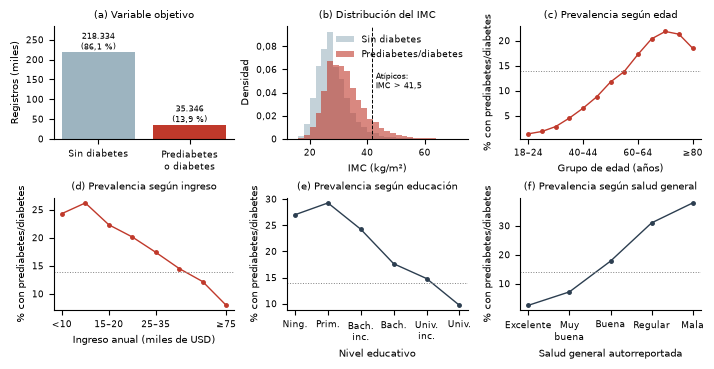

In [5]:
ROJO, AZUL, GRIS = "#c0392b", "#2c3e50", "#9db4c0"
eda = {}
fig, ejes = plt.subplots(2, 3, figsize=(DOS_COL, 3.7))

ax = ejes[0, 0]
conteo = y.value_counts().sort_index()
ax.bar(["Sin diabetes", "Prediabetes\no diabetes"], conteo.values, color=[GRIS, ROJO])
for i, v in enumerate(conteo.values):
    ax.text(i, v, f"{v:,}".replace(",", ".") + f"\n({v / len(y) * 100:.1f} %)".replace(".", ","),
            ha="center", va="bottom", fontsize=6)
ax.set_ylim(0, conteo.max() * 1.3)
ax.set_ylabel("Registros (miles)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1000:.0f}"))
ax.set_title("(a) Variable objetivo")

ax = ejes[0, 1]
imc = df.BMI
q1, q3 = imc.quantile([0.25, 0.75])
limite_imc = q3 + 1.5 * (q3 - q1)
bins = np.arange(12, 101, 2)
ax.hist(imc[y == 0], bins=bins, density=True, alpha=0.6, color=GRIS, label="Sin diabetes")
ax.hist(imc[y == 1], bins=bins, density=True, alpha=0.6, color=ROJO, label="Prediabetes/diabetes")
ax.axvline(limite_imc, color="k", ls="--", lw=0.7)
ax.text(limite_imc + 1.5, ax.get_ylim()[1] * 0.45, f"Atípicos:\nIMC > {limite_imc:.1f}".replace(".", ","),
        fontsize=5.5)
ax.set_xlim(12, 75)
ax.set_xlabel("IMC (kg/m²)")
ax.set_ylabel("Densidad")
coma(ax, "y")
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.02, 1.0))
ax.set_title("(b) Distribución del IMC")
eda["imc"] = {
    "mediana": float(imc.median()), "q1": float(q1), "q3": float(q3), "min": float(imc.min()),
    "max": float(imc.max()), "limite_atipicos": float(limite_imc),
    "pct_atipicos": float((imc > limite_imc).mean()),
    "mediana_sin": float(imc[y == 0].median()), "mediana_con": float(imc[y == 1].median()),
    "pct_obesidad_sin": float((imc[y == 0] >= 30).mean()),
    "pct_obesidad_con": float((imc[y == 1] >= 30).mean()),
}


def prevalencia(ax, col, etiquetas, titulo, xlabel, color=ROJO):
    p = df.groupby(col)[OBJETIVO].mean() * 100
    ax.plot(p.index, p.values, "o-", color=color, ms=2.5, lw=1)
    ax.axhline(y.mean() * 100, color="grey", ls=":", lw=0.7)
    ax.set_xticks(list(etiquetas))
    ax.set_xticklabels(list(etiquetas.values()))
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("% con prediabetes/diabetes")
    return {int(k): float(v / 100) for k, v in p.items()}


eda["prevalencia_edad"] = prevalencia(
    ejes[0, 2], "Age", {1: "18–24", 5: "40–44", 9: "60–64", 13: "≥80"},
    "(c) Prevalencia según edad", "Grupo de edad (años)")
eda["prevalencia_ingreso"] = prevalencia(
    ejes[1, 0], "Income", {1: "<10", 3: "15–20", 5: "25–35", 8: "≥75"},
    "(d) Prevalencia según ingreso", "Ingreso anual (miles de USD)")
eda["prevalencia_educacion"] = prevalencia(
    ejes[1, 1], "Education", {1: "Ning.", 2: "Prim.", 3: "Bach.\ninc.", 4: "Bach.", 5: "Univ.\ninc.", 6: "Univ."},
    "(e) Prevalencia según educación", "Nivel educativo", color=AZUL)
eda["prevalencia_salud_general"] = prevalencia(
    ejes[1, 2], "GenHlth", {1: "Excelente", 2: "Muy\nbuena", 3: "Buena", 4: "Regular", 5: "Mala"},
    "(f) Prevalencia según salud general", "Salud general autorreportada", color=AZUL)
fig.tight_layout(h_pad=0.8, w_pad=0.6)
fig.savefig(FIG / "fig_eda.pdf")
plt.show()

### Correlaciones entre variables

Se usa la correlación de Spearman porque la mayoría de las variables son binarias u ordinales.

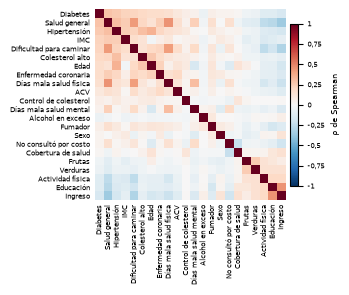

Education  Income      0.451978
GenHlth    PhysHlth    0.451847
           DiffWalk    0.422791
DiffWalk   PhysHlth    0.415022
GenHlth    Income     -0.354253
HighBP     Age         0.344535
dtype: float64
GenHlth                 0.287697
HighBP                  0.263129
BMI                     0.226314
DiffWalk                0.218344
HighChol                0.200276
Age                     0.177684
HeartDiseaseorAttack    0.177282
Income                 -0.163305
Name: Diabetes_binary, dtype: float64


In [6]:
orden = ["GenHlth", "HighBP", "BMI", "DiffWalk", "HighChol", "Age", "HeartDiseaseorAttack",
         "PhysHlth", "Stroke", "CholCheck", "MentHlth", "HvyAlcoholConsump", "Smoker", "Sex",
         "NoDocbcCost", "AnyHealthcare", "Fruits", "Veggies", "PhysActivity", "Education", "Income"]
rho = df[[OBJETIVO] + orden].corr(method="spearman")
fig, ax = plt.subplots(figsize=(UNA_COL, 3.6))
im = ax.imshow(rho.values, cmap="RdBu_r", vmin=-1, vmax=1)
etiq = ["Diabetes"] + [NOMBRES[v] for v in orden]
ax.set_xticks(range(len(etiq)))
ax.set_yticks(range(len(etiq)))
ax.set_xticklabels(etiq, rotation=90, fontsize=5.4)
ax.set_yticklabels(etiq, fontsize=5.4)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.ax.tick_params(labelsize=5)
coma(cb.ax, "y")
cb.set_label("ρ de Spearman", fontsize=5.5)
fig.tight_layout()
fig.savefig(FIG / "fig_correlacion.pdf")
plt.show()

pares = (rho.drop(index=OBJETIVO, columns=OBJETIVO).where(np.triu(np.ones((21, 21)), 1).astype(bool))
         .stack().sort_values(key=abs, ascending=False))
eda["pares_mas_correlacionados"] = [[a, b, float(r)] for (a, b), r in pares.head(6).items()]
eda["correlacion_objetivo"] = rho[OBJETIVO].drop(OBJETIVO).sort_values(key=abs, ascending=False).to_dict()
eda["max_abs_correlacion_entre_predictoras"] = float(pares.abs().max())
resultados["eda"] = eda
print(pares.head(6))
print(rho[OBJETIVO].drop(OBJETIVO).sort_values(key=abs, ascending=False).head(8))

## 3. Estado del arte

El informe resume cinco trabajos que abordan el mismo problema de clasificación: dos usan
exactamente esta base (Ren, 2024; Majcherek et al., 2025), uno la encuesta BRFSS 2014 (Xie et al.,
2019), uno la encuesta NHANES (Dinh et al., 2019) y uno datos hospitalarios (Zou et al., 2018).
Para cada uno se reporta el paradigma, la técnica, la validación, las métricas y los resultados.

## 4. Entrenamiento y evaluación de modelos

### 4.1 Configuración experimental

1. **Partición de prueba.** 20 % estratificado (50.736 registros), con la prevalencia real. No se
   usa en ninguna decisión de modelado.
2. **Submuestreo.** Del 80 % restante se toma una muestra balanceada de 20.000 registros (10.000
   por clase) mediante submuestreo aleatorio de la clase mayoritaria. Atiende el desbalance y el
   costo computacional de SVM y KNN.
3. **Validación.** Búsqueda en rejilla con validación cruzada estratificada de 5 pliegues sobre la
   muestra de entrenamiento, maximizando el AUC-ROC. La estandarización está dentro del *pipeline*,
   así que se ajusta en cada pliegue sin fuga de información.
4. **Métricas.** AUC-ROC (criterio de selección), AUC-PR, sensibilidad, especificidad, precisión,
   F1 y exactitud balanceada. Se reportan en entrenamiento y validación (media ± desviación
   estándar de los 5 pliegues) y en prueba (intervalo de confianza del 95 % por *bootstrap*).

In [7]:
X_pool, X_test, y_pool, y_test = train_test_split(X, y, test_size=0.20, stratify=y,
                                                  random_state=SEMILLA)
N_POR_CLASE = 10_000
rng = np.random.default_rng(SEMILLA)
idx_pos = rng.choice(np.where(y_pool == 1)[0], N_POR_CLASE, replace=False)
idx_neg = rng.choice(np.where(y_pool == 0)[0], N_POR_CLASE, replace=False)
idx = rng.permutation(np.concatenate([idx_pos, idx_neg]))
X_train, y_train = X_pool.iloc[idx], y_pool.iloc[idx]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados["particion"] = {"n_prueba": int(len(X_test)), "n_entrenamiento": int(len(X_train)),
                           "n_pool": int(len(X_pool)), "prevalencia_prueba": float(y_test.mean())}

ESPECIFICIDAD = make_scorer(recall_score, pos_label=0)
METRICAS = {"auc_roc": "roc_auc", "auc_pr": "average_precision", "sensibilidad": "recall",
            "especificidad": ESPECIFICIDAD, "precision": "precision", "f1": "f1",
            "exactitud_balanceada": "balanced_accuracy"}


def escalado(modelo):
    return Pipeline([("escala", StandardScaler()), ("modelo", modelo)])


def puntaje(modelo, Xp):
    """Probabilidad o, si el modelo no la calcula, distancia a la frontera de decisión."""
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(Xp)[:, 1]
    return modelo.decision_function(Xp)


def metricas_prueba(y_real, s, y_pred, n_boot=500):
    """Métricas en prueba con intervalo de confianza del 95 % por bootstrap."""
    y_real, s, y_pred = np.asarray(y_real), np.asarray(s), np.asarray(y_pred)

    def calc(yr, ss, yp):
        return {"auc_roc": roc_auc_score(yr, ss), "auc_pr": average_precision_score(yr, ss),
                "sensibilidad": recall_score(yr, yp), "especificidad": recall_score(yr, yp, pos_label=0),
                "precision": precision_score(yr, yp), "f1": f1_score(yr, yp),
                "exactitud_balanceada": balanced_accuracy_score(yr, yp)}

    base = calc(y_real, s, y_pred)
    r = np.random.default_rng(SEMILLA)
    muestras = {k: [] for k in base}
    for _ in range(n_boot):
        i = r.integers(0, len(y_real), len(y_real))
        for k, v in calc(y_real[i], s[i], y_pred[i]).items():
            muestras[k].append(v)
    return {k: {"valor": float(v), "ic95": [float(np.percentile(muestras[k], 2.5)),
                                             float(np.percentile(muestras[k], 97.5))]}
            for k, v in base.items()}

### 4.2 Modelos y mallas de hiperparámetros

In [8]:
MODELOS = {
    "Regresión logística": ("Paramétrico", escalado(LogisticRegression(max_iter=2000)),
                            {"modelo__C": [0.001, 0.01, 0.1, 1, 10]}),
    "KNN": ("No paramétrico", escalado(KNeighborsClassifier()),
            {"modelo__n_neighbors": [5, 25, 51, 101, 151, 201, 301],
             "modelo__weights": ["uniform", "distance"]}),
    "Random Forest": ("Ensamble de árboles",
                      RandomForestClassifier(n_estimators=300, random_state=SEMILLA, n_jobs=1),
                      {"max_depth": [None, 12], "min_samples_leaf": [1, 10, 30]}),
    "MLP": ("Red neuronal artificial",
            escalado(MLPClassifier(max_iter=400, early_stopping=True, random_state=SEMILLA)),
            {"modelo__hidden_layer_sizes": [(32,), (64, 32)],
             "modelo__alpha": [1e-4, 1e-2, 1]}),
    "SVM": ("Máquina de vectores de soporte", escalado(SVC(kernel="rbf", random_state=SEMILLA)),
            {"modelo__C": [0.1, 1, 10], "modelo__gamma": ["scale", 0.01]}),
}

busquedas, evaluacion = {}, {}
for nombre, (familia, modelo, malla) in MODELOS.items():
    t0 = time.time()
    b = GridSearchCV(modelo, malla, scoring=METRICAS, refit="auc_roc", cv=cv, n_jobs=N_JOBS,
                     return_train_score=True)
    b.fit(X_train, y_train)
    busquedas[nombre] = b
    i = b.best_index_
    cvr = b.cv_results_
    evaluacion[nombre] = {
        "familia": familia,
        "malla": {k.replace("modelo__", ""): [str(v) for v in vals] for k, vals in malla.items()},
        "n_configuraciones": int(len(cvr["params"])),
        "mejores_parametros": {k.replace("modelo__", ""): str(v) for k, v in b.best_params_.items()},
        "entrenamiento": {m: [float(cvr[f"mean_train_{m}"][i]), float(cvr[f"std_train_{m}"][i])]
                          for m in METRICAS},
        "validacion": {m: [float(cvr[f"mean_test_{m}"][i]), float(cvr[f"std_test_{m}"][i])]
                       for m in METRICAS},
        "tiempo_busqueda_s": time.time() - t0,
    }
    print(f"{nombre:<20} AUC val {cvr['mean_test_auc_roc'][i]:.4f} ± {cvr['std_test_auc_roc'][i]:.4f}"
          f"  {b.best_params_}  ({time.time() - t0:.0f} s)", flush=True)

Regresión logística  AUC val 0.8229 ± 0.0038  {'modelo__C': 0.01}  (5 s)


KNN                  AUC val 0.8117 ± 0.0051  {'modelo__n_neighbors': 151, 'modelo__weights': 'uniform'}  (103 s)


Random Forest        AUC val 0.8262 ± 0.0026  {'max_depth': None, 'min_samples_leaf': 10}  (46 s)


MLP                  AUC val 0.8262 ± 0.0039  {'modelo__alpha': 1, 'modelo__hidden_layer_sizes': (32,)}  (14 s)


SVM                  AUC val 0.8258 ± 0.0047  {'modelo__C': 1, 'modelo__gamma': 0.01}  (307 s)


### 4.3 Efecto de los hiperparámetros

AUC-ROC de entrenamiento (línea discontinua) y de validación (línea continua, ± una desviación
estándar) para cada valor de la malla.

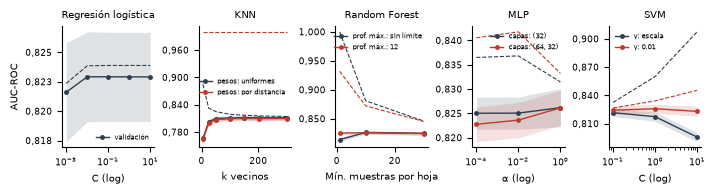

In [9]:
def malla_como_tabla(nombre):
    """Resultados de toda la malla: parámetros como texto (None queda como 'None')."""
    cvr = busquedas[nombre].cv_results_
    p = pd.DataFrame([{k.replace("modelo__", ""): str(v) for k, v in d.items()} for d in cvr["params"]])
    for m in ("mean_test_auc_roc", "std_test_auc_roc", "mean_train_auc_roc"):
        p[m] = cvr[m]
    return p


def curva_hiper(ax, nombre, param_x, param_linea, etiqueta_x, log=False):
    p = malla_como_tabla(nombre)
    grupos = p[param_linea].unique() if param_linea else [None]
    for j, valor in enumerate(grupos):
        sel = (p[param_linea] == valor) if param_linea else np.ones(len(p), bool)
        d = p[sel].assign(x=p.loc[sel, param_x].astype(float)).sort_values("x")
        color = [AZUL, ROJO][j % 2]
        nombre_p = {"weights": "pesos", "max_depth": "prof. máx.", "hidden_layer_sizes": "capas",
                    "gamma": "γ"}.get(param_linea, param_linea)
        valor_p = {"uniform": "uniformes", "distance": "por distancia", "None": "sin límite",
                   "(32,)": "(32)", "scale": "escala"}.get(valor, valor)
        etiqueta = f"{nombre_p}: {valor_p}" if param_linea else "validación"
        val, de = d.mean_test_auc_roc.values, d.std_test_auc_roc.values
        ax.plot(d.x, val, "o-", color=color, ms=2.5, lw=1, label=etiqueta)
        ax.fill_between(d.x, val - de, val + de, color=color, alpha=0.15, lw=0)
        ax.plot(d.x, d.mean_train_auc_roc, "--", color=color, lw=0.8)
    if log:
        ax.set_xscale("log")
    ax.set_xlabel(etiqueta_x)
    ax.set_title(nombre)
    coma(ax, "y", dec=3)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))


resultados["mallas"] = {n: malla_como_tabla(n).to_dict(orient="records") for n in busquedas}


fig, ejes = plt.subplots(1, 5, figsize=(DOS_COL, 1.95), sharey=False)
curva_hiper(ejes[0], "Regresión logística", "C", None, "C (log)", log=True)
curva_hiper(ejes[1], "KNN", "n_neighbors", "weights", "k vecinos")
curva_hiper(ejes[2], "Random Forest", "min_samples_leaf", "max_depth", "Mín. muestras por hoja")
curva_hiper(ejes[3], "MLP", "alpha", "hidden_layer_sizes", "α (log)", log=True)
curva_hiper(ejes[4], "SVM", "C", "gamma", "C (log)", log=True)
ejes[0].set_ylabel("AUC-ROC")
for ax in ejes:
    ax.legend(frameon=False, fontsize=4.8, loc="best")
fig.tight_layout(w_pad=0.4)
fig.savefig(FIG / "fig_hiperparametros.pdf")
plt.show()

### 4.4 Resultados en el conjunto de prueba

Regresión logística  AUC prueba 0.8190 [0.8143474498153482, 0.8237514542700285]  AUC-PR 0.393  sens 0.759  esp 0.727


KNN                  AUC prueba 0.8076 [0.8026936029578426, 0.8125703805996245]  AUC-PR 0.382  sens 0.776  esp 0.696


Random Forest        AUC prueba 0.8207 [0.8156620035094564, 0.8253207213392344]  AUC-PR 0.410  sens 0.786  esp 0.708


MLP                  AUC prueba 0.8242 [0.8193788015144149, 0.8288295575958623]  AUC-PR 0.411  sens 0.794  esp 0.705


SVM                  AUC prueba 0.8220 [0.8172520600298183, 0.8267145764327732]  AUC-PR 0.398  sens 0.815  esp 0.682


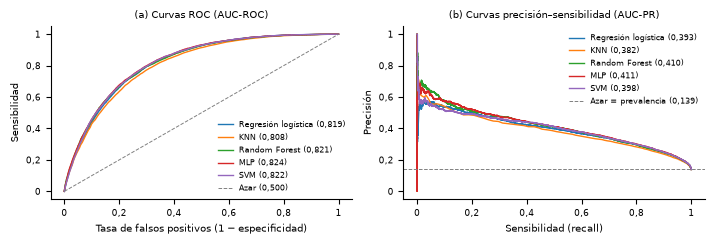

In [10]:
curvas, ajustados = {}, {}
for nombre, b in busquedas.items():
    mejor = b.best_estimator_
    s = puntaje(mejor, X_test)
    y_pred = mejor.predict(X_test)
    evaluacion[nombre]["prueba"] = metricas_prueba(y_test, s, y_pred)
    ajustados[nombre] = mejor
    curvas[nombre] = (roc_curve(y_test, s), precision_recall_curve(y_test, s))
    pr = evaluacion[nombre]["prueba"]
    print(f"{nombre:<20} AUC prueba {pr['auc_roc']['valor']:.4f} {pr['auc_roc']['ic95']}  "
          f"AUC-PR {pr['auc_pr']['valor']:.3f}  sens {pr['sensibilidad']['valor']:.3f}  "
          f"esp {pr['especificidad']['valor']:.3f}")
resultados["modelos"] = evaluacion
resultados["linea_base_auc_pr"] = float(y_test.mean())

fig, ejes = plt.subplots(1, 2, figsize=(DOS_COL, 2.45))
for nombre, ((fpr, tpr, _), (prec, rec, _)) in curvas.items():
    a = evaluacion[nombre]["prueba"]
    ejes[0].plot(fpr, tpr, lw=1, label=f"{nombre} ({a['auc_roc']['valor']:.3f})".replace(".", ","))
    ejes[1].plot(rec, prec, lw=1, label=f"{nombre} ({a['auc_pr']['valor']:.3f})".replace(".", ","))
ejes[0].plot([0, 1], [0, 1], "--", color="grey", lw=0.7, label="Azar (0,500)")
ejes[1].axhline(y_test.mean(), ls="--", color="grey", lw=0.7,
                label=f"Azar = prevalencia ({y_test.mean():.3f})".replace(".", ","))
ejes[0].set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ejes[0].set_ylabel("Sensibilidad")
ejes[0].set_title("(a) Curvas ROC (AUC-ROC)")
ejes[1].set_xlabel("Sensibilidad (recall)")
ejes[1].set_ylabel("Precisión")
ejes[1].set_title("(b) Curvas precisión–sensibilidad (AUC-PR)")
for ax in ejes:
    coma(ax)
    ax.legend(frameon=False, fontsize=5.5, loc="upper right" if ax is ejes[1] else "lower right")
fig.tight_layout()
fig.savefig(FIG / "fig_curvas.pdf")
plt.show()

**Control del submuestreo.** Regresión logística entrenada con los 202.944 registros de
entrenamiento y pesos por clase, para verificar que entrenar con 20.000 no pierde información.

In [11]:
C_lr = float(evaluacion["Regresión logística"]["mejores_parametros"]["C"])
lr_completa = escalado(LogisticRegression(C=C_lr, class_weight="balanced", max_iter=2000))
lr_completa.fit(X_pool, y_pool)
resultados["control_lr_completa"] = {
    "auc_roc": float(roc_auc_score(y_test, lr_completa.predict_proba(X_test)[:, 1])),
    "n": int(len(X_pool))}
print(resultados["control_lr_completa"])

{'auc_roc': 0.8196370120329295, 'n': 202944}


**Determinantes sociales frente a factores clínicos.** AUC-ROC en prueba de una regresión
logística y un Random Forest entrenados con cada bloque de variables.

In [12]:
BLOQUES = {
    "Socioeconómico y acceso": ["Income", "Education", "AnyHealthcare", "NoDocbcCost"],
    "Demográfico": ["Age", "Sex"],
    "Estilo de vida": ["Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump"],
    "Clínico": ["HighBP", "HighChol", "CholCheck", "BMI", "Stroke", "HeartDiseaseorAttack",
                "GenHlth", "MentHlth", "PhysHlth", "DiffWalk"],
}
combinaciones = dict(BLOQUES)
combinaciones["Social + demográfico"] = BLOQUES["Socioeconómico y acceso"] + BLOQUES["Demográfico"]
combinaciones["Todas"] = VARIABLES
cfg_rf = {k: (None if v == "None" else int(v))
          for k, v in evaluacion["Random Forest"]["mejores_parametros"].items()}
bloques = {}
for etiqueta, cols in combinaciones.items():
    lr = escalado(LogisticRegression(C=C_lr, max_iter=2000)).fit(X_train[cols], y_train)
    rf = RandomForestClassifier(n_estimators=300, random_state=SEMILLA, n_jobs=N_JOBS,
                                **cfg_rf).fit(X_train[cols], y_train)
    bloques[etiqueta] = {"n_variables": len(cols),
                         "auc_lr": float(roc_auc_score(y_test, lr.predict_proba(X_test[cols])[:, 1])),
                         "auc_rf": float(roc_auc_score(y_test, rf.predict_proba(X_test[cols])[:, 1]))}
resultados["bloques"] = bloques
pd.DataFrame(bloques).T

,n_variables,auc_lr,auc_rf
Socioeconómico y acceso,4.0,0.641493,0.639151
Demográfico,2.0,0.650823,0.658244
Estilo de vida,5.0,0.618381,0.619117
Clínico,10.0,0.806851,0.807872
Social + demográfico,6.0,0.700285,0.705346
Todas,21.0,0.819000,0.820727


## 5. Reducción de dimensión

Se evalúan los **dos mejores modelos según el AUC-ROC de validación** (no de prueba, para no
contaminar la selección).

In [13]:
ranking_val = sorted(evaluacion, key=lambda n: -evaluacion[n]["validacion"]["auc_roc"][0])
MEJORES = ranking_val[:2]
resultados["ranking_validacion"] = ranking_val
print("Dos mejores modelos:", MEJORES)


def evaluar_representacion(transformador, columnas=None):
    """AUC de validación cruzada y métricas de prueba de los dos mejores modelos
    con una representación dada (la transformación se ajusta dentro de cada pliegue)."""
    salida = {}
    Xtr = X_train if columnas is None else X_train[columnas]
    Xte = X_test if columnas is None else X_test[columnas]
    for nombre in MEJORES:
        base = clone(busquedas[nombre].best_estimator_)
        modelo = base.steps[-1][1] if isinstance(base, Pipeline) else base
        pasos = [("escala", StandardScaler())]
        if transformador is not None:
            pasos.append(("reduccion", clone(transformador)))
        pipe = Pipeline(pasos + [("modelo", modelo)])
        t0 = time.time()
        r = cross_validate(pipe, Xtr, y_train, cv=cv, scoring={"auc_roc": "roc_auc"}, n_jobs=N_JOBS)
        pipe.fit(Xtr, y_train)
        s = puntaje(pipe, Xte)
        salida[nombre] = {
            "validacion_auc": [float(r["test_auc_roc"].mean()), float(r["test_auc_roc"].std())],
            "prueba": metricas_prueba(y_test, s, pipe.predict(Xte), n_boot=300),
            "tiempo_s": time.time() - t0,
        }
    return salida


reduccion = {"mejores_modelos": MEJORES,
             "referencia_21": evaluar_representacion(None)}

Dos mejores modelos: ['Random Forest', 'MLP']


### 5.1 Análisis individual de las variables

Para cada variable se calculan tres medidas de su relación con la clase: la correlación de
Spearman, la información mutua y un índice de discriminación (el AUC-ROC que se obtiene usando la
variable sola como puntaje, reflejado como max(AUC, 1 − AUC)).

In [14]:
discretas = [c not in ("BMI", "MentHlth", "PhysHlth") for c in VARIABLES]
im_ = mutual_info_classif(X_train, y_train, discrete_features=discretas, random_state=SEMILLA)
individual = pd.DataFrame({
    "spearman": [spearmanr(X_train[v], y_train)[0] for v in VARIABLES],
    "informacion_mutua": im_,
    "auc_individual": [max(a, 1 - a) for a in (roc_auc_score(y_train, X_train[v]) for v in VARIABLES)],
}, index=VARIABLES).sort_values("auc_individual", ascending=False)
# Candidatas a eliminar: discriminan casi como el azar (AUC individual < 0,55) y comparten muy poca
# información con la clase (|ρ| < 0,10).
candidatas = individual[(individual.auc_individual < 0.55) & (individual.spearman.abs() < 0.10)].index.tolist()
conservadas = [v for v in VARIABLES if v not in candidatas]
reduccion["individual"] = individual.to_dict(orient="index")
reduccion["candidatas_eliminar"] = candidatas
reduccion["seleccion"] = evaluar_representacion(None, columnas=conservadas)
reduccion["seleccion"]["n_variables"] = len(conservadas)
print("Candidatas a eliminar:", candidatas)
individual.round(3)

Candidatas a eliminar: ['Smoker', 'Fruits', 'Veggies', 'MentHlth', 'Sex', 'HvyAlcoholConsump', 'NoDocbcCost', 'AnyHealthcare']


,spearman,informacion_mutua,auc_individual
GenHlth,0.409,0.090,0.728
HighBP,0.384,0.076,0.690
BMI,0.326,0.058,0.688
Age,0.263,0.049,0.651
HighChol,0.299,0.045,0.649
Income,-0.229,0.027,0.630
DiffWalk,0.267,0.037,0.616
PhysHlth,0.219,0.026,0.614
Education,-0.174,0.016,0.596
PhysActivity,-0.167,0.014,0.576


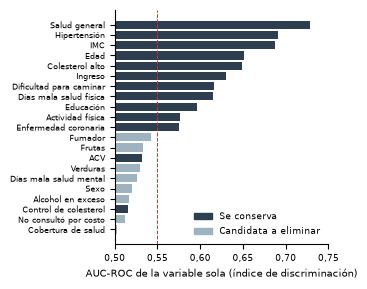

In [15]:
fig, ax = plt.subplots(figsize=(UNA_COL, 2.9))
ind = individual.iloc[::-1]
colores = [GRIS if v in candidatas else AZUL for v in ind.index]
ax.barh([NOMBRES[v] for v in ind.index], ind.auc_individual - 0.5, left=0.5, color=colores)
ax.axvline(0.55, color=ROJO, ls="--", lw=0.7)
ax.set_xlim(0.5, max(0.75, ind.auc_individual.max() + 0.02))
ax.set_xlabel("AUC-ROC de la variable sola (índice de discriminación)")
from matplotlib.patches import Patch  # noqa: E402
ax.legend(handles=[Patch(color=AZUL, label="Se conserva"), Patch(color=GRIS, label="Candidata a eliminar")],
          frameon=False, loc="lower right")
coma(ax, "x", dec=2)
ax.tick_params(axis="y", labelsize=5.8)
fig.tight_layout()
fig.savefig(FIG / "fig_individual.pdf")
plt.show()

### 5.2 Extracción lineal: PCA

**Criterio.** Se comparan dos criterios estándar sobre las variables estandarizadas: el de Kaiser
(componentes con autovalor mayor que 1, es decir, que explican más varianza que una variable
original) y el del 90 % de varianza explicada. Se elige el de Kaiser: con un tercio de las
dimensiones pierde alrededor de una centésima de AUC, mientras que el del 90 % casi no reduce la
dimensión (las variables están poco correlacionadas) y en Random Forest no mejora el resultado.

In [16]:
Z = StandardScaler().fit_transform(X_train)
pca_total = PCA(random_state=SEMILLA).fit(Z)
autovalores = pca_total.explained_variance_
var_acum = np.cumsum(pca_total.explained_variance_ratio_)
k_kaiser = int((autovalores > 1).sum())
k_90 = int(np.searchsorted(var_acum, 0.90) + 1)
reduccion["pca"] = {
    "autovalores": autovalores.tolist(), "varianza_acumulada": var_acum.tolist(),
    "k_kaiser": k_kaiser, "k_90": k_90,
    "varianza_kaiser": float(var_acum[k_kaiser - 1]),
    "cargas_pc1": dict(sorted(zip(VARIABLES, pca_total.components_[0].round(3).tolist()),
                              key=lambda t: -abs(t[1]))[:6]),
    "kaiser": evaluar_representacion(PCA(n_components=k_kaiser, random_state=SEMILLA)),
    "var90": evaluar_representacion(PCA(n_components=k_90, random_state=SEMILLA)),
}
print(f"Kaiser: {k_kaiser} componentes ({var_acum[k_kaiser - 1]:.1%}); 90 %: {k_90} componentes")
for crit in ("kaiser", "var90"):
    for n in MEJORES:
        print(crit, n, reduccion["pca"][crit][n]["validacion_auc"])

Kaiser: 7 componentes (53.3%); 90 %: 17 componentes
kaiser Random Forest [0.8145275750000002, 0.0037699978403508147]
kaiser MLP [0.8178754249999999, 0.004756606909473385]
var90 Random Forest [0.815749325, 0.003746730398460777]
var90 MLP [0.8215372750000001, 0.0038766340324113864]


### 5.3 Extracción no lineal: UMAP

**Criterio.** UMAP no tiene una medida de varianza explicada, así que el número de componentes se
elige por desempeño: se prueban k ∈ {2, 3, 5, 8, 10} sobre una partición de validación (80/20) de
la muestra de entrenamiento con el mejor modelo, y se escoge el menor k cuyo AUC esté a menos de
0,005 del máximo. Hiperparámetros de UMAP: 30 vecinos, distancia mínima 0.

In [17]:
import umap  # noqa: E402

X_a, X_v, y_a, y_v = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train,
                                      random_state=SEMILLA)
esc_a = StandardScaler().fit(X_a)
K_UMAP = [2, 3, 5, 8, 10]
umap_val = {}
mejor_modelo = MEJORES[0]
for k in K_UMAP:
    t0 = time.time()
    u = umap.UMAP(n_components=k, n_neighbors=30, min_dist=0.0, random_state=SEMILLA)
    Ea = u.fit_transform(esc_a.transform(X_a))
    Ev = u.transform(esc_a.transform(X_v))
    base = clone(busquedas[mejor_modelo].best_estimator_)
    m = base.steps[-1][1] if isinstance(base, Pipeline) else base
    m = Pipeline([("escala", StandardScaler()), ("modelo", m)]).fit(Ea, y_a)
    umap_val[k] = float(roc_auc_score(y_v, puntaje(m, Ev)))
    print(f"UMAP k={k}: AUC validación {umap_val[k]:.4f} ({time.time() - t0:.0f} s)", flush=True)
k_umap = min(k for k in K_UMAP if umap_val[k] >= max(umap_val.values()) - 0.005)

# Evaluación final: UMAP ajustado con toda la muestra de entrenamiento y los dos mejores modelos.
esc = StandardScaler().fit(X_train)
u = umap.UMAP(n_components=k_umap, n_neighbors=30, min_dist=0.0, random_state=SEMILLA)
E_tr = u.fit_transform(esc.transform(X_train))
E_te = u.transform(esc.transform(X_test))
umap_final = {}
for nombre in MEJORES:
    base = clone(busquedas[nombre].best_estimator_)
    m = base.steps[-1][1] if isinstance(base, Pipeline) else base
    pipe = Pipeline([("escala", StandardScaler()), ("modelo", m)]).fit(E_tr, y_train)
    s = puntaje(pipe, E_te)
    umap_final[nombre] = {"validacion_auc_k": umap_val[k_umap],
                          "prueba": metricas_prueba(y_test, s, pipe.predict(E_te), n_boot=300)}
reduccion["umap"] = {"k_evaluados": K_UMAP, "auc_validacion_por_k": umap_val, "k_elegido": k_umap,
                     "resultados": umap_final}
print("k elegido:", k_umap)

UMAP k=2: AUC validación 0.7575 (73 s)


UMAP k=3: AUC validación 0.7621 (23 s)


UMAP k=5: AUC validación 0.7707 (28 s)


UMAP k=8: AUC validación 0.7748 (27 s)


UMAP k=10: AUC validación 0.7782 (32 s)


k elegido: 8


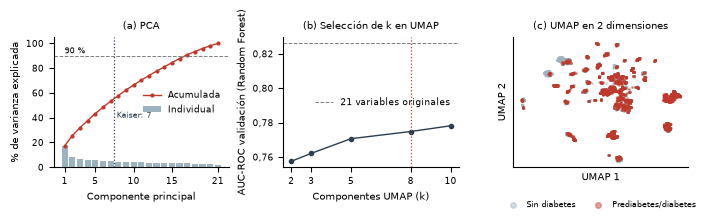

In [18]:
u2 = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=SEMILLA)
emb2 = u2.fit_transform(esc.transform(X_train))
fig, ejes = plt.subplots(1, 3, figsize=(DOS_COL, 2.2))
ax = ejes[0]
ax.bar(range(1, 22), pca_total.explained_variance_ratio_ * 100, color=GRIS, label="Individual")
ax.plot(range(1, 22), var_acum * 100, "o-", color=ROJO, ms=2, lw=1, label="Acumulada")
ax.axhline(90, color="grey", ls="--", lw=0.7)
ax.axvline(k_kaiser + 0.5, color=AZUL, ls=":", lw=0.9)
ax.text(k_kaiser + 0.8, 40, f"Kaiser: {k_kaiser}", fontsize=5.5, color=AZUL)
ax.text(1, 92, "90 %", fontsize=5.5)
ax.set_xticks([1, 5, 10, 15, 21])
ax.set_xlabel("Componente principal")
ax.set_ylabel("% de varianza explicada")
ax.set_title("(a) PCA")
ax.legend(frameon=False, loc="center right")
ax = ejes[1]
ax.plot(K_UMAP, [umap_val[k] for k in K_UMAP], "o-", color=AZUL, ms=3, lw=1)
ax.axvline(k_umap, color=ROJO, ls=":", lw=0.9)
ax.axhline(reduccion["referencia_21"][mejor_modelo]["validacion_auc"][0], color="grey", ls="--", lw=0.7,
           label="21 variables originales")
ax.set_xticks(K_UMAP)
ax.set_xlabel("Componentes UMAP (k)")
ax.set_ylabel(f"AUC-ROC validación ({mejor_modelo})")
ax.set_title("(b) Selección de k en UMAP")
coma(ax, "y", dec=2)
ax.legend(frameon=False, loc="center right")
ax = ejes[2]
muestra = rng.choice(len(emb2), 6000, replace=False)
for clase, color, etiqueta in [(0, GRIS, "Sin diabetes"), (1, ROJO, "Prediabetes/diabetes")]:
    sel = muestra[y_train.values[muestra] == clase]
    ax.scatter(emb2[sel, 0], emb2[sel, 1], s=1, alpha=0.45, color=color, label=etiqueta, rasterized=True)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("(c) UMAP en 2 dimensiones")
ax.legend(markerscale=4, frameon=False, fontsize=5.5, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
fig.tight_layout(w_pad=0.8)
fig.savefig(FIG / "fig_reduccion.pdf", dpi=300)
plt.show()

resultados["reduccion"] = reduccion

## 6. Discusión y conclusiones

- **Desempeño.** Los cinco modelos alcanzan un AUC-ROC de prueba entre 0,81 y 0,82 y una
  sensibilidad cercana al 80 %. Los cuatro mejores quedan dentro de la variación de la validación
  cruzada; KNN es el más débil. El AUC-PR (0,38–0,41) casi triplica su línea base (0,139).
- **Determinantes sociales.** Las variables clínicas concentran la capacidad predictiva; las
  socioeconómicas y demográficas discriminan por sí solas (AUC ≈ 0,70) pero aportan poco una vez se
  conocen las clínicas.
- **Reducción de dimensión.** La selección de variables retira 8 de 21 casi sin pérdida; PCA con el
  criterio de Kaiser (7 componentes) pierde alrededor de una centésima; UMAP pierde mucho más
  porque sus vecindarios no coinciden con la separación entre clases.
- **Limitaciones.** Datos autorreportados, etiqueta que agrupa prediabetes y diabetes, diseño
  transversal, pesos muestrales del BRFSS no usados y población de Estados Unidos.

La siguiente celda guarda todos los números que usa el informe en `resultados/resultados.json`.

In [19]:
(RES / "resultados.json").write_text(json.dumps(resultados, indent=2, ensure_ascii=False, default=float),
                                     encoding="utf-8")
resumen = pd.DataFrame({n: {"AUC val": e["validacion"]["auc_roc"][0],
                            "AUC prueba": e["prueba"]["auc_roc"]["valor"],
                            "AUC-PR prueba": e["prueba"]["auc_pr"]["valor"],
                            "Sens.": e["prueba"]["sensibilidad"]["valor"],
                            "Esp.": e["prueba"]["especificidad"]["valor"]}
                        for n, e in evaluacion.items()}).T
resumen.round(3)

,AUC val,AUC prueba,AUC-PR prueba,Sens.,Esp.
Regresión logística,0.823,0.819,0.393,0.759,0.727
KNN,0.812,0.808,0.382,0.776,0.696
Random Forest,0.826,0.821,0.410,0.786,0.708
MLP,0.826,0.824,0.411,0.794,0.705
SVM,0.826,0.822,0.398,0.815,0.682
